<a href="https://colab.research.google.com/github/Pranathipasapu/Rainfall-Prediction-ML/blob/main/Rainfall_Prediction_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/Pranathipasapu/Rainfall-Prediction-ML/refs/heads/main/dataset/Rainfall.csv")

In [5]:
print(df.head())

   day  pressure   maxtemp  temparature  mintemp  dewpoint  humidity   cloud   \
0    1     1025.9     19.9         18.3     16.8      13.1         72      49   
1    2     1022.0     21.7         18.9     17.2      15.6         81      83   
2    3     1019.7     20.3         19.3     18.0      18.4         95      91   
3    4     1018.9     22.3         20.6     19.1      18.8         90      88   
4    5     1015.9     21.3         20.7     20.2      19.9         95      81   

  rainfall  sunshine           winddirection  windspeed  
0      yes       9.3                    80.0       26.3  
1      yes       0.6                    50.0       15.3  
2      yes       0.0                    40.0       14.2  
3      yes       1.0                    50.0       16.9  
4      yes       0.0                    40.0       13.7  


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB
None


In [7]:
print(df.isnull().sum())

day                       0
pressure                  0
maxtemp                   0
temparature               0
mintemp                   0
dewpoint                  0
humidity                  0
cloud                     0
rainfall                  0
sunshine                  0
         winddirection    1
windspeed                 1
dtype: int64


In [8]:
df.columns = df.columns.str.strip()

In [9]:
imputer = SimpleImputer(strategy='mean')

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [11]:
df.replace({'yes':1, 'no':0}, inplace=True)

/tmp/ipykernel_810/2314881541.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'yes':1, 'no':0}, inplace=True)


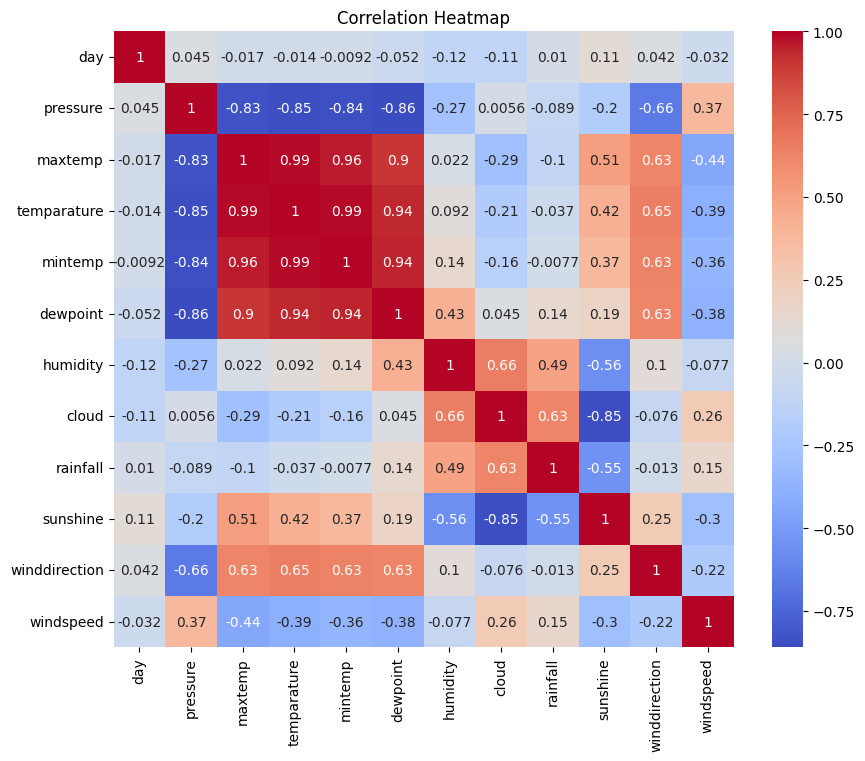

In [12]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


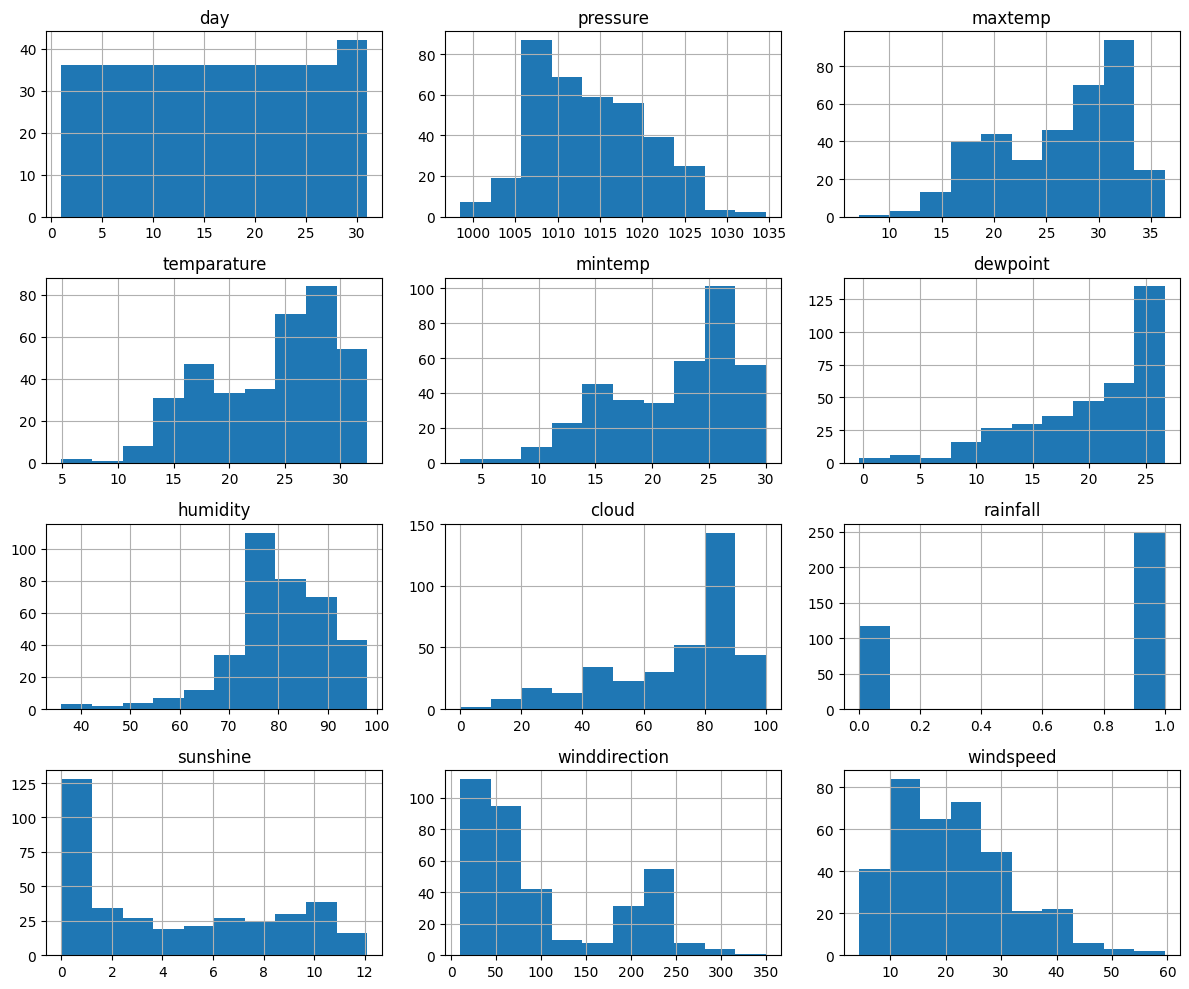

In [13]:
# Distribution Plot
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

In [14]:
# Features and Target
X = df.drop(['rainfall', 'day'], axis=1)
y = df['rainfall']

In [15]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [17]:
# Decision Tree Model
# -----------------------------
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)


In [18]:
# Random Forest Model
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [19]:
# Evaluation Function
# -----------------------------
def evaluate_model(name, y_true, y_pred):

    print(f"\n{name} Performance")
    print("-" * 30)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred) # Corrected typo from f_pred to y_pred

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                    annot=True,
                    fmt='d',
                    cmap='Blues')

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [20]:
# The confusion matrix plotting is now part of the evaluate_model function.


Decision Tree Performance
------------------------------
Accuracy : 0.7027027027027027
Precision: 0.8043478260869565
Recall   : 0.74
F1-Score : 0.7708333333333334

Classification Report
              precision    recall  f1-score   support

           0       0.54      0.62      0.58        24
           1       0.80      0.74      0.77        50

    accuracy                           0.70        74
   macro avg       0.67      0.68      0.67        74
weighted avg       0.72      0.70      0.71        74



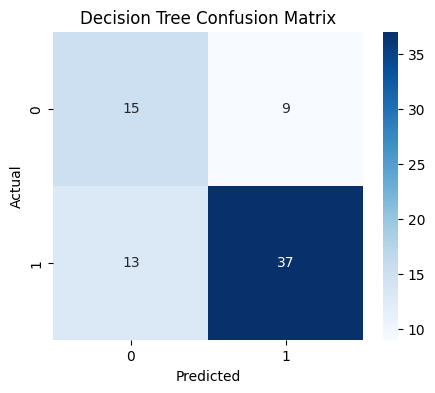

In [21]:
evaluate_model('Decision Tree', y_test, dt_pred)


Random Forest Performance
------------------------------
Accuracy : 0.7972972972972973
Precision: 0.8070175438596491
Recall   : 0.92
F1-Score : 0.8598130841121495

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.54      0.63        24
           1       0.81      0.92      0.86        50

    accuracy                           0.80        74
   macro avg       0.79      0.73      0.75        74
weighted avg       0.79      0.80      0.79        74



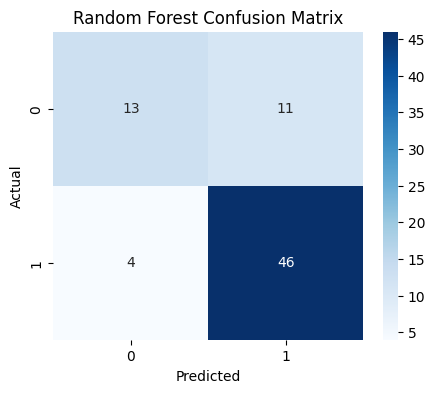

In [22]:
evaluate_model('Random Forest', y_test, rf_pred)

In [23]:
# Compare Accuracy
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("\nModel Comparison")
print("-----------------------")
print("Decision Tree Accuracy :", dt_acc)
print("Random Forest Accuracy:", rf_acc)

if rf_acc > dt_acc:
    print("\nRandom Forest performed better.")
else:
    print("\nDecision Tree performed better.")


Model Comparison
-----------------------
Decision Tree Accuracy : 0.7027027027027027
Random Forest Accuracy: 0.7972972972972973

Random Forest performed better.
